In [ ]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("course_final.csv", encoding = "utf-8")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 533993 entries, 0 to 533992
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   course_id             533993 non-null  str    
 1   userid_DI             533993 non-null  str    
 2   registered            533993 non-null  int64  
 3   viewed                533993 non-null  int64  
 4   explored              533993 non-null  int64  
 5   certified             533993 non-null  int64  
 6   final_cc_cname_DI     533993 non-null  str    
 7   LoE_DI                533993 non-null  str    
 8   YoB                   452939 non-null  float64
 9   gender                533993 non-null  str    
 10  grade                 491268 non-null  str    
 11  start_time_DI         533993 non-null  str    
 12  last_event_DI         533993 non-null  str    
 13  nevents               532186 non-null  float64
 14  ndays_act             532186 non-null  float64
 15  nplay_video

In [4]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_ratio(%)' : (df.isnull().mean()*100).round(2)
}).sort_values(by='missing_ratio(%)', ascending=False)
missing_summary

,missing_count,missing_ratio(%)
nplay_video,185071,34.66
LoE_num,87859,16.45
age_cleaned,81706,15.30
age_raw,81054,15.18
YoB,81054,15.18
age,81054,15.18
age_final,81054,15.18
nchapters,58210,10.90
grade,42725,8.00
ndays_act,1807,0.34


In [5]:
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


In [6]:
df['nplay_video'].describe()

count    348922.000000
mean         60.313540
std         314.961586
min           0.000000
25%           0.000000
50%           1.000000
75%          20.000000
max       98517.000000
Name: nplay_video, dtype: float64

In [7]:
# 각 단계별 총 인원 합계
n_reg = df['registered'].sum()
n_view = df['viewed'].sum()
n_exp = df['explored'].sum()

# 등록자 중 실제 강의를 본 비율
reg_to_view = (n_view / n_reg) * 100
# 이탈률
drop_out_reg_to_view = 100 - reg_to_view

# 강의를 본 사람 중 탐색한 비율
view_to_exp = (n_exp / n_view) * 100
# 이탈률
drop_out_view_to_exp = 100 - view_to_exp

# 전체 등록자 대비 탐색 비율
total_conversion = (n_exp / n_reg) * 100

print(f"========== 단계별 참여 및 이탈 구조 ==========")
print(f"registered -> viewed 전환율 : {reg_to_view:.2f}%")
print(f"registered -> viewed 이탈률 : {drop_out_reg_to_view:.2f}%")
print()
print(f"viewed -> explored 전환율 : {view_to_exp:.2f}%")
print(f"viewed -> explored 이탈률 : {drop_out_view_to_exp:.2f}%")
print()
print(f"최종 explored 전환율 : {total_conversion:.2f}%")

========== 단계별 참여 및 이탈 구조 ==========
registered -> viewed 전환율 : 60.93%
registered -> viewed 이탈률 : 39.07%

viewed -> explored 전환율 : 11.55%
viewed -> explored 이탈률 : 88.45%

최종 explored 전환율 : 7.04%


In [8]:
import plotly.graph_objects as go

stages = ["Registered", "Viewed", "Explored"]
counts = [n_reg, n_view, n_exp]

fig = go.Figure(go.Funnel(
    y = stages,
    x = counts,
    textinfo = "value+percent initial+percent previous",
    marker = {"color": ["#636EFA", "#EF553B", "#00CC96"]}
))

fig.update_layout(title_text='학습 퍼널 및 단계별 전환율 진단')
fig.show() 

In [9]:
df_viewed = df[df['viewed'] == 1]

df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compare_dist(df_fail, df_suc, column_name, title=None):
    """
    두 그룹(실패 vs 성공)의 특정 컬럼 분포와 중앙값을 비교하는 함수 (에러 방지 기능 추가)
    """
    plt.figure(figsize=(12, 6))

    # 🚨 [핵심 해결책] 결측치(NaN) 제거 및 인덱스 초기화!
    # Series 형태로 뽑아서 깨끗하게 세탁합니다.
    data_fail = df_fail[column_name].dropna().reset_index(drop=True)
    data_suc = df_suc[column_name].dropna().reset_index(drop=True)

    # 1. 중앙값 계산
    median_fail = data_fail.median()
    median_suc = data_suc.median()

    # 2. 분포 그래프 (data=df 대신, 정제된 x=Series를 직접 넣습니다)
    sns.histplot(x=data_fail, color='red', label='Fail Group', 
                 stat='proportion', common_norm=False, alpha=0.3, element="step")

    sns.histplot(x=data_suc, color='blue', label='Success Group', 
                 stat='proportion', common_norm=False, alpha=0.3, element="step")

    # 3. 중앙값 수직선 표시
    plt.axvline(median_fail, color='darkred', linestyle='--', linewidth=2, 
                label=f'Fail Median: {median_fail:.1f}')
    plt.axvline(median_suc, color='darkblue', linestyle='--', linewidth=2, 
                label=f'Success Median: {median_suc:.1f}')

    # 4. 그래프 디테일 설정
    if title is None:
        title = f'Normalized Distribution of {column_name} (Fail vs Success)'
        
    plt.title(title, fontsize=15, pad=20)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Proportion of Users', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.show()

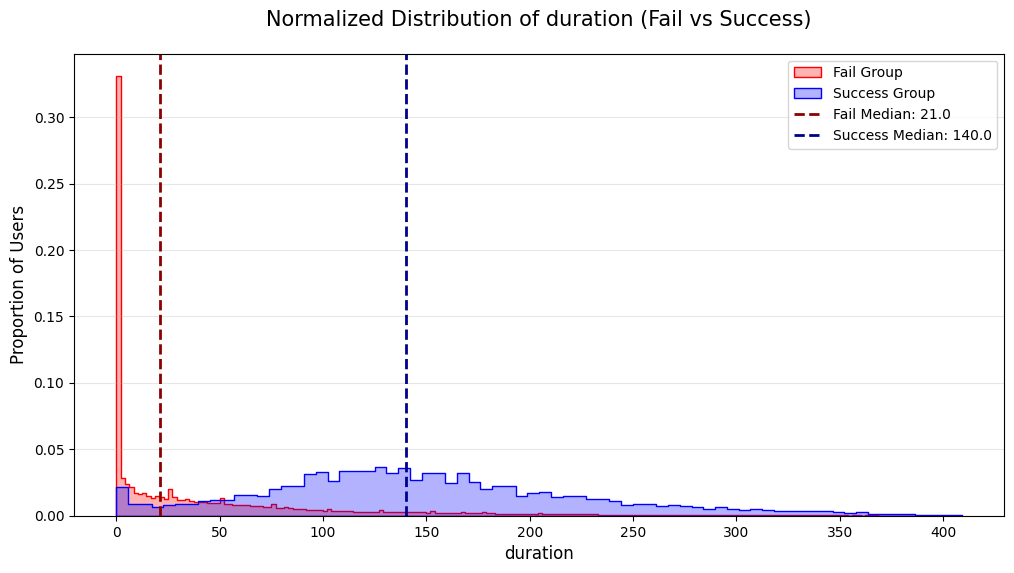

In [67]:
plot_compare_dist(df_fail_explored, df_suc_explored, column_name='duration')

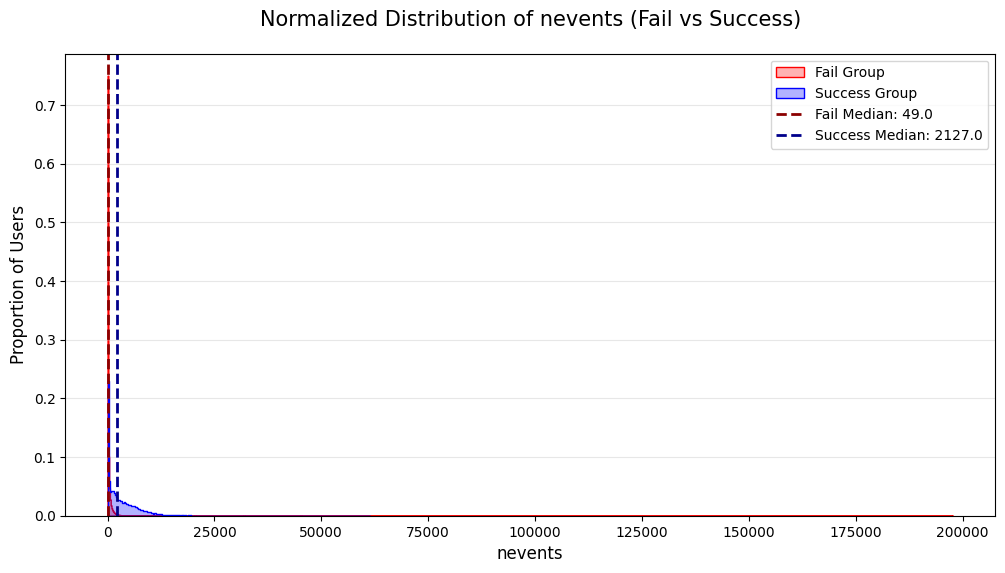

In [68]:
plot_compare_dist(df_fail_explored, df_suc_explored, column_name='nevents')

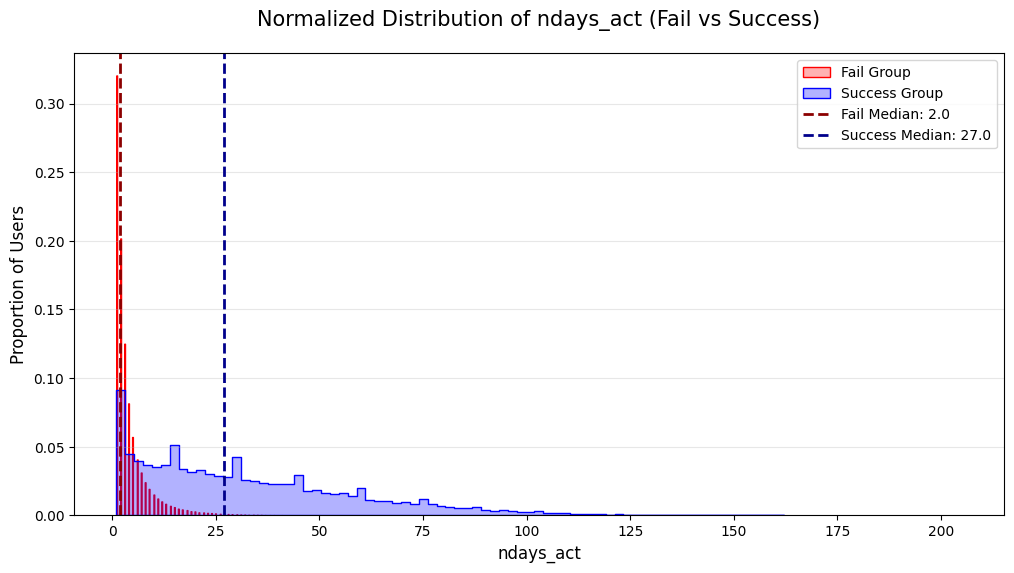

In [69]:
plot_compare_dist(df_fail_explored, df_suc_explored, column_name='ndays_act')

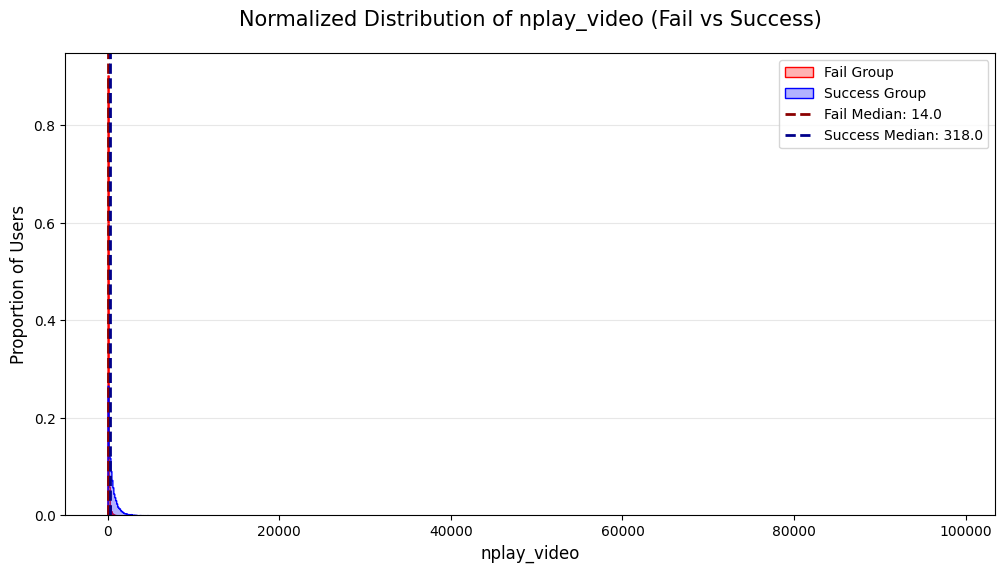

In [70]:
plot_compare_dist(df_fail_explored, df_suc_explored, column_name='nplay_video')

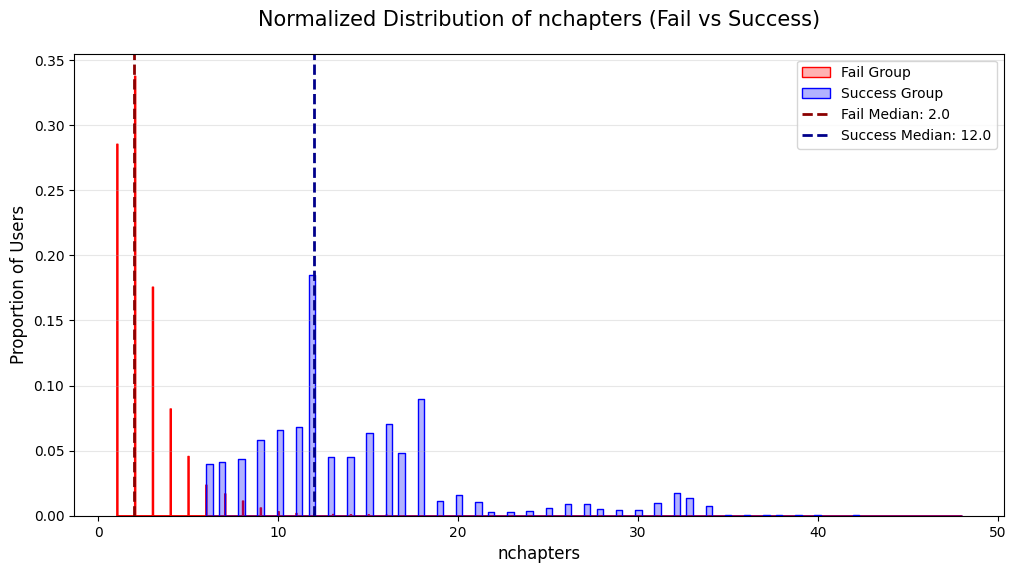

In [71]:
plot_compare_dist(df_fail_explored, df_suc_explored, column_name='nchapters')

In [72]:
df_suc_explored['nchapters'].min()

np.float64(6.0)

In [73]:
df_viewed.columns

Index(['course_id', 'userid_DI', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade',
       'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration',
       'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original',
       'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group',
       'exam_flag', 'LoE_num'],
      dtype='str')

In [74]:
df_viewed.loc[df_viewed['nplay_video'].isna(),'course_id'].value_counts()

course_id
HarvardX/CS50x/2012            41374
HarvardX/ER22x/2013_Spring     32112
MITx/6.00x/2013_Spring         16918
HarvardX/CB22x/2013_Spring     16234
MITx/8.MReV/2013_Summer         6193
MITx/6.002x/2012_Fall           5664
MITx/6.00x/2012_Fall            5099
HarvardX/PH207x/2012_Fall       3514
MITx/14.73x/2013_Spring         3069
MITx/8.02x/2013_Spring          2745
MITx/7.00x/2013_Spring          2739
HarvardX/PH278x/2013_Spring     2456
MITx/3.091x/2013_Spring         2397
MITx/6.002x/2013_Spring         1774
MITx/3.091x/2012_Fall           1064
MITx/2.01x/2013_Spring           750
Name: count, dtype: int64

1. 규리님 아이디어 구체화 및 빠진 부분 채우기

In [20]:
# 이탈자 유형 세분화

# Step 1. 진입 전 이탈
step1 = ((df['registered'] == 1) & (df['viewed'] == 0)).sum()

# Step 2-1. 진입 직후 이탈
step2_1 = ((df['viewed'] == 1) & (df['nevents'].isna()) & (df['explored'] == 0)).sum()

# Step 2-2. 탐색 시도 후 이탈
step2_2 = ((df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)).sum()

# Step 3. explored 1인 사람
step3_total = df[df['explored'] == 1]

print(f"진입 전 이탈 : {step1:,}명")
print(f"진입 직후 이탈 : {step2_1:,}명")
print(f"탐색 시도 후 이탈 : {step2_2:,}명")

진입 전 이탈 : 208,632명
진입 직후 이탈 : 1,807명
탐색 시도 후 이탈 : 285,970명


In [1]:
target_group = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]

# 확인할 지표 리스트
check_cols = ['nchapters', 'ndays_act', 'nplay_video']

print(f"===== [탐색 시도 후 이탈자] ({len(target_group):,}명) 대상 활동 지표 기록 현황 =====")

for col in check_cols:
    exists_count = target_group[col].notna().sum()
    exists_ratio = (exists_count / len(target_group)) * 100
    
    print(f"[{col}] 기록 존재 : {exists_count:,}명 ({exists_ratio:.2f}%)")
    print(f"[{col}] 결측(NaN) -> 도달 못함 : {len(target_group) - exists_count:,}명")
    print("-" * 50)

NameError: name 'df' is not defined

In [76]:
# viewed 그룹에서 어디에서 많이 이탈하는가
def leave_sort_x(df, col):
    df_proportion = df.value_counts(col).reset_index().sort_values(col)
    df_proportion['proportion'] = df_proportion['count'] / len(df)
    df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()
    df_proportion

    start_point = pd.DataFrame({col:[0], 'fail_rate':[1.0]})
    df_plot = pd.concat([start_point, df_proportion]).sort_values(col).reset_index(drop = True)
    display(df_plot.head(30))

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_plot, x=col, y='fail_rate', color='red', linewidth=2)

    plt.xlim(0, 10)
    plt.ylim(0, 1.1) 
    plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
    plt.grid(True, alpha=0.3)

    plt.show()

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,0,0.763174,68153.0,0.236826
2,1,0.690528,20906.0,0.072647
3,2,0.668886,6228.0,0.021642
4,3,0.653377,4463.0,0.015509
5,4,0.640190,3795.0,0.013187
6,5,0.628233,3441.0,0.011957
7,6,0.616307,3432.0,0.011926
8,7,0.604541,3386.0,0.011766
9,8,0.594332,2938.0,0.010209


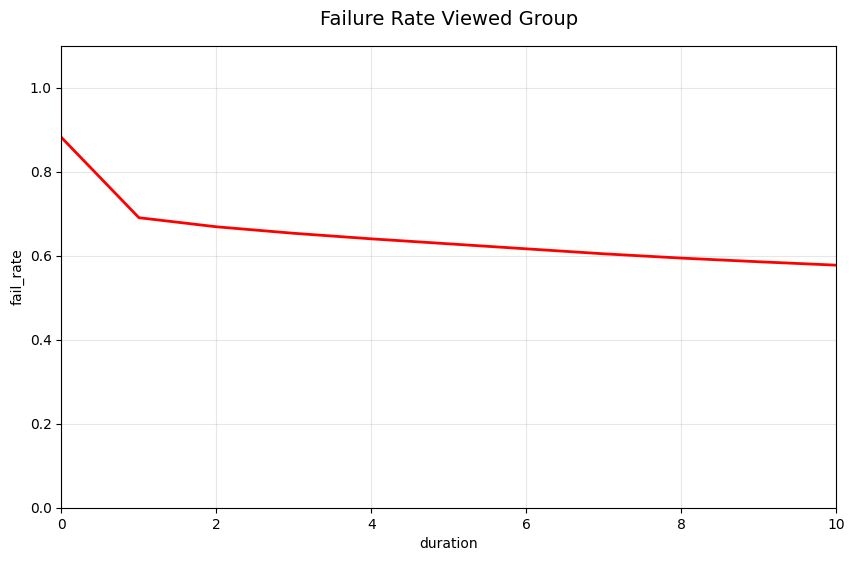

In [79]:
leave_sort_x(df_fail_explored, 'duration')

,ndays_act,fail_rate,count,proportion
0,0.0,1.000000,NaN,NaN
1,1.0,0.681580,91634.0,0.318420
2,2.0,0.481116,57689.0,0.200464
3,3.0,0.356849,35761.0,0.124266
4,4.0,0.275762,23335.0,0.081087
5,5.0,0.218992,16337.0,0.056770
6,6.0,0.178496,11654.0,0.040497
7,7.0,0.147448,8935.0,0.031048
8,8.0,0.123446,6907.0,0.024001
9,9.0,0.104251,5524.0,0.019195


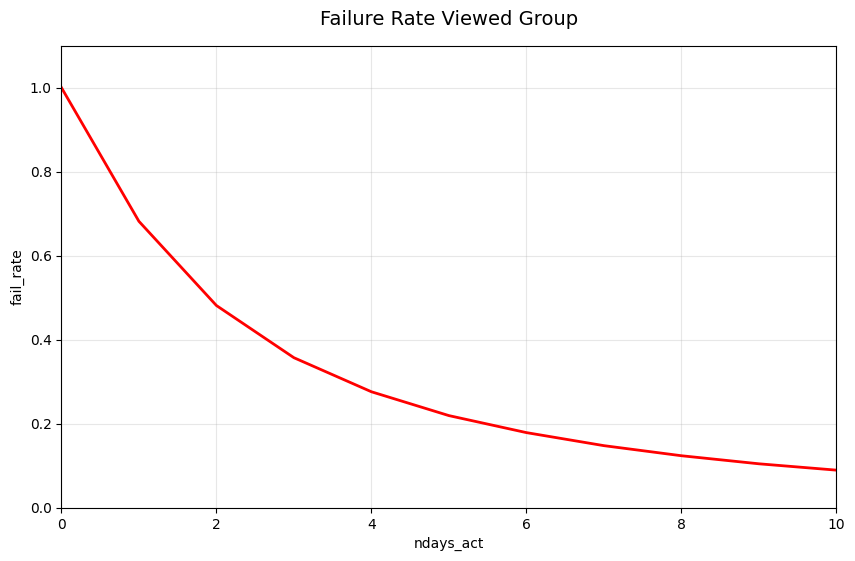

In [80]:
leave_sort_x(df_fail_explored, 'ndays_act')

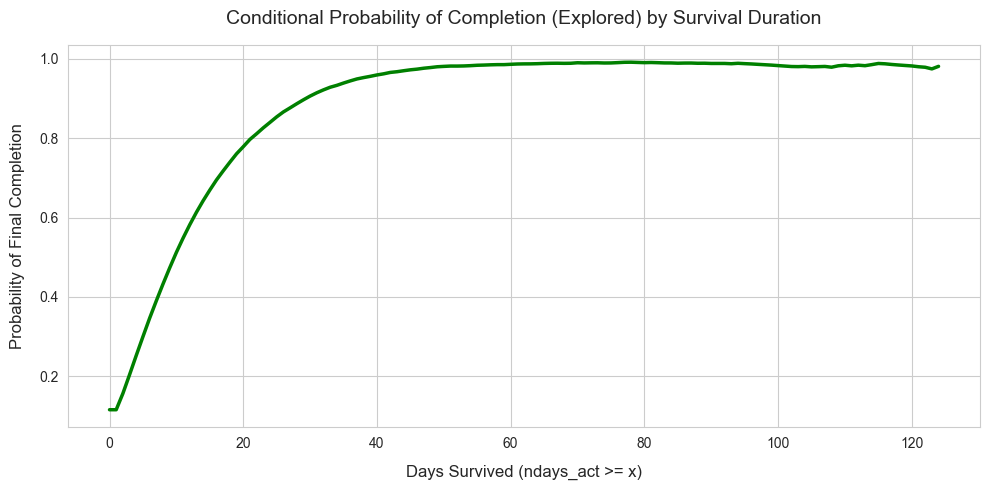

In [82]:
conditional_results = []
max_days = int(df_viewed['ndays_act'].max())

# x일보다 적은 구간은 제외하면서 그래프를 그려봄
for x in range(max_days + 1):
    survivors = df_viewed[df_viewed['ndays_act'] >= x]

    if len(survivors) > 100:
        success_count = survivors['explored'].sum()
        prob = success_count / len(survivors)

        conditional_results.append({'day' : x, 'cond_prob': prob, 'sample_size': len(survivors)})
df_cond = pd.DataFrame(conditional_results)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid") 

sns.lineplot(data=df_cond, x='day', y='cond_prob', color='green', linewidth=2.5)

plt.title('Conditional Probability of Completion (Explored) by Survival Duration', fontsize=14, pad=15)
plt.xlabel('Days Survived (ndays_act >= x)', fontsize=12, labelpad=10)
plt.ylabel('Probability of Final Completion', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [18]:
# 탐색 시도 후 이탈자 행동 분석
avg_video_target = target_group['nplay_video'].mean()
print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {avg_video_target:.2f}회")

탐색 시도 후 이탈자 평균 영상 재생 횟수 : 50.52회


In [21]:
# explored 그룹 행동 분석
avg_video = step3_total['nplay_video'].mean()
print(f"explored 유저 평균 영상 재생 횟수 : {avg_video:.2f}회")

explored 유저 평균 영상 재생 횟수 : 550.49회


In [22]:
# explored 유형 활동 중심 세분화
step3_total = df[df['explored'] == 1]
step3_total_count = (df['explored'] == 1).sum()

# Step 3-1. 영상 몰입형 
step3_1 = (step3_total['nplay_video'] > avg_video).sum()

# Step 3-2 일반 달성자
step3_2 = (step3_total['nplay_video'] <= avg_video).sum()

print(f"=== Step 3. explored 집단 상세 분석 ===")
print(f"explored 유저 수 : {step3_total_count:,}명")
print(f"영상 몰입형: {step3_1:,}명")
print(f"일반 달성자: {step3_2:,}명")
print()
missing_count = step3_total['nplay_video'].isna().sum()
print(f"영상 기록이 없는(NaN) explored 유저 : {missing_count:,}명")

=== Step 3. explored 집단 상세 분석 ===
explored 유저 수 : 37,584명
영상 몰입형: 7,760명
일반 달성자: 16,015명

영상 기록이 없는(NaN) explored 유저 : 13,809명


In [23]:
from scipy import stats

# 1. explored 내 두 그룹 정의
success_group = df[df['explored'] == 1]
success_video_high = success_group[success_group['nplay_video'] > success_group['nplay_video'].mean()]
success_video_nan = success_group[success_group['nplay_video'].isna()]

# 2. 전체 이벤트(nevents) 평균 차이 검정
t_stat, p_val = stats.ttest_ind(success_video_high['nevents'], success_video_nan['nevents'], equal_var=False)

print(f"영상 몰입형 평균 이벤트 발생 횟수 : {success_video_high['nevents'].mean():.2f}회")
print(f"영상 기록이 없는 (NaN) 평균 이벤트 발생 횟수: {success_video_nan['nevents'].mean():.2f}회")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n결론: 두 집단의 활동 방식이 통계적으로 확연히 다름")
else:
    print("\n결론: 활동량 차이가 크지 않음 (다른 요인이 있을 수 있음)")

영상 몰입형 평균 이벤트 발생 횟수 : 8024.67회
영상 기록이 없는 (NaN) 평균 이벤트 발생 횟수: 617.94회
P-value: 0.0000e+00

결론: 두 집단의 활동 방식이 통계적으로 확연히 다름


-------------------

## 다시

In [466]:
from scipy.stats import mannwhitneyu
# 탐색 시도 후 이탈자 
churn_group_video = df[(df['viewed'] == 1) & (df['nevents'] > 0) & (df['explored'] == 0)]['nplay_video'].fillna(0)

# explored 된 유저
success_group_video = df[df['explored'] == 1]['nplay_video'].fillna(0)

# Mann-Whitney U 검정 실시
stat, p = mannwhitneyu(churn_group_video, success_group_video)

print("=== 이탈자 vs explored 유저 영상 재생 횟수 차이 검정 ===")
print(f"탐색 시도 후 이탈자 평균 영상 재생 횟수 : {churn_group_video.mean():.2f}회")
print(f"explored 유저 평균 영상 재생 횟수 : {success_group_video.mean():.2f}회")
print(f"P-value: {p:.4e}")

# 3. 결과 해석
if p < 0.05:
    print("\n 결과 : 두 집단 간 영상 재생 횟수 차이는 통계적으로 매우 유의미함")
    print(f" 인사이트 : explored 유저는 탐색 시도 후 이탈자보다 약 {success_group_video.mean()/churn_group_video.mean():.1f}배 더 많은 영상을 소비함")
else:
    print("\n 결과 : 두 집단 간 통계적으로 유의미한 차이가 발견되지 않음")

=== 이탈자 vs explored 유저 영상 재생 횟수 차이 검정 ===
탐색 시도 후 이탈자 평균 영상 재생 횟수 : 27.82회
explored 유저 평균 영상 재생 횟수 : 348.23회
P-value: 0.0000e+00

 결과 : 두 집단 간 영상 재생 횟수 차이는 통계적으로 매우 유의미함
 인사이트 : explored 유저는 탐색 시도 후 이탈자보다 약 12.5배 더 많은 영상을 소비함


- 이탈자들의 경우 30회 미만 구간에서 가장 많은 이탈 발생
- 영상 재생 10회, 20회 달성 시마다 푸시 알림, 학습 포인트 지급 등 심리적 완주 독려

----------------

In [467]:
# 그룹별 explored 유저 학력 분포
# 영상 몰입형 
video_high = step3_total[step3_total['nplay_video'] > step3_total['nplay_video'].mean()]

# 영상 기록 NaN형
video_zero = step3_total[step3_total['nplay_video'].isna()]

# 학력 분포 
print("=== [영상 몰입형] 학력 비중 ===")
print(video_high['LoE_DI'].value_counts(normalize=True) * 100)

print("\n=== [영상 기록 NaN형] 학력 비중 ===")
print(video_zero['LoE_DI'].value_counts(normalize=True) * 100)

=== [영상 몰입형] 학력 비중 ===
LoE_DI
Master's               27.396907
unknown                26.572165
Bachelor's             25.257732
Secondary              15.412371
Doctorate               3.724227
Less than Secondary     1.636598
Name: proportion, dtype: float64

=== [영상 기록 NaN형] 학력 비중 ===
LoE_DI
Bachelor's             30.241147
Secondary              28.742125
Master's               18.096893
unknown                17.633427
Less than Secondary     3.475994
Doctorate               1.810413
Name: proportion, dtype: float64


- 고학력자 : 영상 몰입형
- 저학력자 : 영상 없이 성공
- 학사 : 표준적인 학습자 층

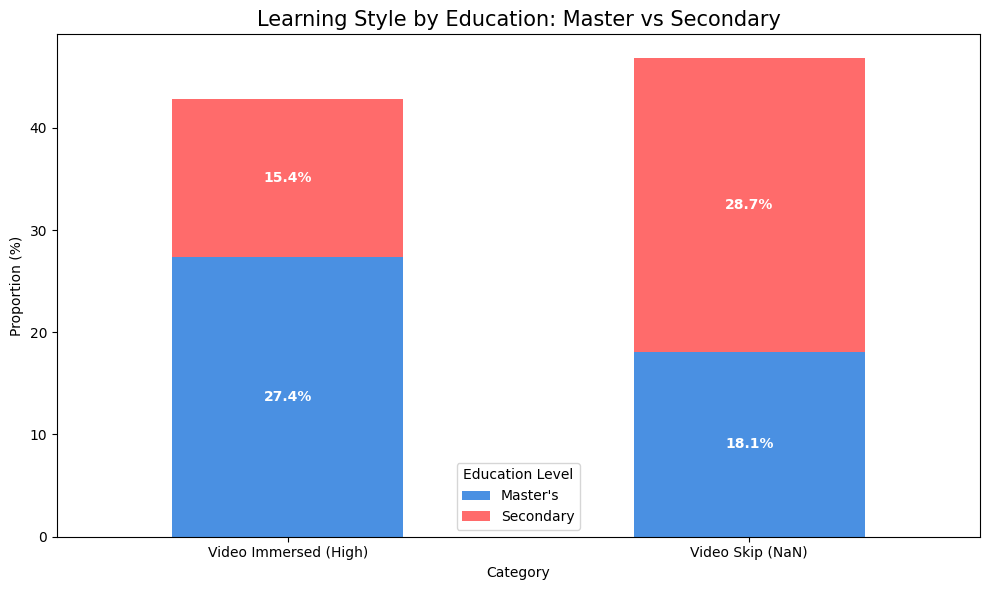

In [468]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Category': ['Video Immersed (High)', 'Video Skip (NaN)'],
    "Master's": [27.4, 18.1],
    'Secondary': [15.4, 28.7]
}
plot_df = pd.DataFrame(data).set_index('Category')

# 시각화
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4A90E2', '#FF6B6B'])
plt.title('Learning Style by Education: Master vs Secondary', fontsize=15)
plt.ylabel('Proportion (%)')
plt.xticks(rotation=0)
plt.legend(title='Education Level')

# 수치 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [469]:
# 학력에 따른 학습 스타일 차이 검정
# 학력별 다른 학습 가이드 제공
!pip install scipy
from scipy.stats import chi2_contingency

from scipy import stats

# 그룹 복사 및 그룹 표시용 컬럼 추가 
v_high = video_high.copy()
v_zero = video_zero.copy()

v_high['group'] = 'High_Video'
v_zero['group'] = 'Zero_Video'

# 인덱스 무시하고 합치기 
compare_df = pd.concat([v_high, v_zero], ignore_index=True)

# 교차표(Contingency Table) 생성
contingency_table = pd.crosstab(compare_df['LoE_DI'], compare_df['group'])

# 카이제곱 검정 실시
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("결과: 학력에 따른 학습 스타일 차이는 통계적으로 매우 유의미함 (귀무가설 기각)")
else:
    print("결과: 학력과 학습 스타일 간의 유의미한 차이가 발견되지 않음")

카이제곱 통계량: 935.3384
P-value: 5.9774e-200
결과: 학력에 따른 학습 스타일 차이는 통계적으로 매우 유의미함 (귀무가설 기각)


In [470]:
# explored 유저 분석
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')

target = df[df['explored'] == 1]
print("========== Explored 유저의 grade 통계 ==========")
print(target['grade'].describe())

========== Explored 유저의 grade 통계 ==========
count    36692.000000
mean         0.454398
std          0.389863
min          0.000000
25%          0.000000
50%          0.470000
75%          0.850000
max          1.010000
Name: grade, dtype: float64


explored 된 유저 중 시험 미응시 비율 : 2.11%



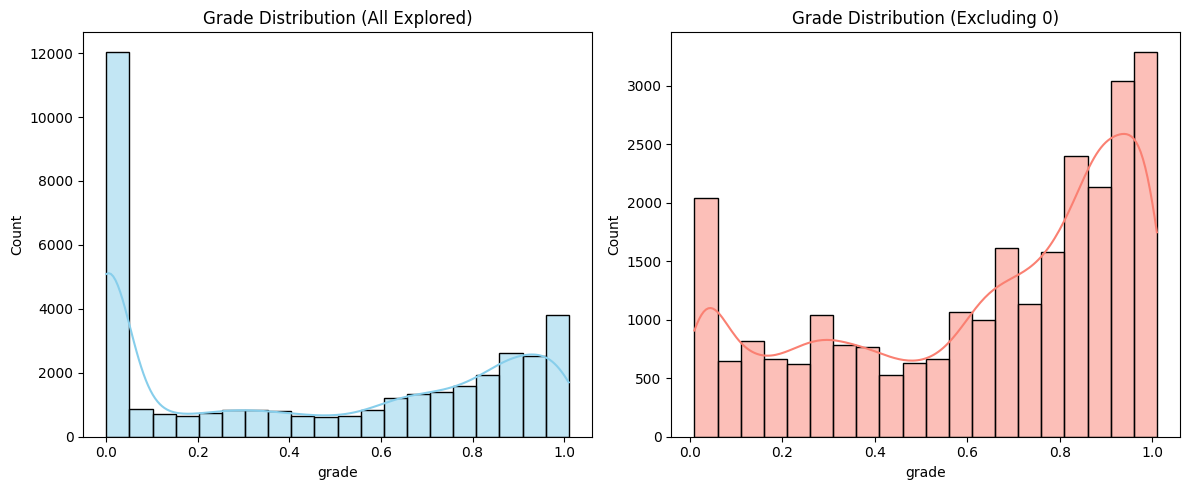

In [471]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# explored 된 유저 분석
target = df[df['explored'] == 1]
no_exam_rate = (len(target[target['exam_flag'] == 0]) / len(target)) * 100
print(f"explored 된 유저 중 시험 미응시 비율 : {no_exam_rate:.2f}%")
print()

# 시각화 (0점 포함 vs 0점 제외)
plt.figure(figsize=(12, 5))

# [왼쪽] 전체 분포 (0점 포함)
plt.subplot(1, 2, 1)
sns.histplot(target['grade'].dropna(), bins=20, color='skyblue', kde=True)
plt.title('Grade Distribution (All Explored)')

# [오른쪽] 실제 성취도 (0점 제외)
plt.subplot(1, 2, 2)
active_target = target[target['grade'] > 0]
sns.histplot(active_target['grade'], bins=20, color='salmon', kde=True)
plt.title('Grade Distribution (Excluding 0)')

plt.tight_layout()
plt.show()

- 본 서비스는 심화 학습자의 97.9%가 시험에 응시할 만큼 완주 의지가 높지만, 전체 유저의 88%가 초반 탐색 단계에서 이탈함
- 따라서 심화 학습자 관리보다는 초기 이탈 구간의 심리적/기술적 허들을 낮추는 온보딩 전략이 성장의 핵심 과제임
- grade 0이 많은 현상 : 학습의 질보다 양 / 시험 성적보다 정보 습득 / 평가에 대한 심리적 허들 / 평가에 참여할 동기 부족 

In [472]:
# 활동 지표 통계값
stats = df[['nevents', 'ndays_act']].describe()
display(stats)

# 임계값 설정
# ndays_act의 중앙값이 활동 일수 기준 1일에 불과하여, 전체 50%가 단기 이탈자임을 확인
# 하위 25%는 활동 이벤트 발생 수가 1회 이하로
nevents_thershold = stats.loc['25%', 'nevents']
ndays_thershold = stats.loc['25%', 'ndays_act']

# 평균 활동 지표
avg_nevents = df['nevents'].mean()
avg_ndays_act = df['ndays_act'].mean()

# 활동 이벤트가 적은 이용자
low_activity_count = len(df[df['nevents'] <= nevents_thershold])
low_activity_rate = (low_activity_count / len(df)) * 100

# 활동 일수가 짧은 이용자
low_eng_count = len(df[df['ndays_act'] <= ndays_thershold])
low_eng_rate = (low_eng_count / len(df)) * 100

print(f"========== 전체 유저 활동 지표 분석 ==========")
print(f"평균 활동 이벤트 수  : {avg_nevents:.2f}")
print(f"평균 활동 일수 : {avg_ndays_act:.2f}일")
print(f"활동 이벤트가 적은 유저 비율 : {low_activity_rate:.2f}%")
print(f"활동 일수가 적은 유저 비율 : {low_eng_rate:.2f}%")

,nevents,ndays_act
count,532186.000000,532186.000000
mean,357.682042,4.825112
std,1390.863751,11.151017
min,0.000000,0.000000
25%,1.000000,1.000000
50%,11.000000,1.000000
75%,105.000000,4.000000
max,197757.000000,205.000000


========== 전체 유저 활동 지표 분석 ==========
평균 활동 이벤트 수  : 357.68
평균 활동 일수 : 4.83일
활동 이벤트가 적은 유저 비율 : 28.95%
활동 일수가 적은 유저 비율 : 52.39%


In [473]:
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'])
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'])

# 학습 지속 기간
df['duration'] = (df['last_event_DI'] - df['start_time_DI']).dt.days

# 평균 및 중앙 학습 지속 기간
avg_duration = df['duration'].mean()
med_duration = df['duration'].median()

# 초기 이탈 비율